In [1]:
!pip install timm

Defaulting to user installation because normal site-packages is not writeable


In [3]:
# imports
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
from torchvision.transforms import ToTensor
import timm
from tqdm import tqdm
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

/usr/pkg/miniconda-23.9.0/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /auto/pkg/miniconda-23.9.0/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/home/users/if42/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Download FER2013 with 7 emotion classes
train_dataset = datasets.ImageFolder(
    root="./labeled_images"
)

# Length of Training Dataset
print(len(train_dataset))

35891


In [ ]:
total = len(train_dataset)
train_len = int(0.7 * total)
val_len = int(0.2 * total)
test_len = total - train_len - val_len
train_ds, val_ds, test_ds = random_split(train_dataset, [train_len, val_len, test_len])

# Train/Val/Test Split
print(len(train_ds), len(val_ds), len(test_ds))

25123 7178 3590


Image preprocessing (for both segmentation & ViT input)<br><br>

Simple normalization for segmentation;<br>
ViT‑specific normalization at 224×224.

In [ ]:
vit_size = 224
mean, std = [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]

preprocess = transforms.Compose([
    transforms.Resize((vit_size, vit_size)),
    transforms.Grayscale(num_output_channels=3),  
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

def collate_fn(batch):
    ims, lbls = [], []
    for x, y in batch:
        ims.append(preprocess(x))
        lbls.append(y)
    return torch.stack(ims), torch.tensor(lbls)

Dataloaders

In [9]:
BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [ ]:
# Inspecting train_loader
imgs, lbls = next(iter(train_loader))

print("Data Structure for the First Batch:")
print(f"Image Batch Shape (Batch, C, H, W): {imgs.shape}")
print(f"Label Batch Shape (Batch Size): {lbls.shape}")
print(f"Data Type of Tensors: {imgs.dtype}")

print("Verifying Data Labels")
for i in range(BATCH_SIZE):
    print(lbls[i].item())

--- Data Structure for the First Batch ---
Image Batch Shape (Batch, C, H, W): torch.Size([32, 3, 224, 224])
Label Batch Shape (Batch Size): torch.Size([32])
Data Type of Tensors: torch.float32
Verifying Data Labels
5
0
3
6
4
5
0
0
4
4
3
0
0
5
2
2
5
4
3
6
6
4
3
6
2
2
1
0
3
6
1
6


Load pretrained ViT & apply LoRA adapters<br>
We’ll use a simple LoRA adapter implementation (adds low‑rank matrices to attention weights).

In [ ]:
vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=7)

# Simple LoRA utility (rank‑r adapters on attention projections)
def add_lora_to_linear(linear_layer, r=8, alpha=16):
    in_dim, out_dim = linear_layer.in_features, linear_layer.out_features
    
    linear_layer.lora_A = nn.Linear(in_dim, r, bias=False)
    linear_layer.lora_B = nn.Linear(r, out_dim, bias=False)
    
    nn.init.zeros_(linear_layer.lora_B.weight) 
    
    linear_layer.lora_scale = alpha / r

    # Freeze original layer
    for p in linear_layer.parameters():
        p.requires_grad_(False)

    def new_forward(x, orig_forward=linear_layer.forward):
        return orig_forward(x) + linear_layer.lora_scale * linear_layer.lora_B(linear_layer.lora_A(x))
    
    linear_layer.forward = new_forward

for name, module in list(vit.named_modules()):
    if isinstance(module, nn.Linear) and 'attn.qkv' in name:
        add_lora_to_linear(module, r=4)

Training loop (fine‑tune with LoRA)

Device: cuda


Epoch 1/10 [Val]: 100%|██████████| 225/225 [00:46<00:00,  4.87it/s]


Epoch 1: Train Loss: 1.1768 | Val Acc: 64.59%
  >>> New best model saved! (Acc: 64.59%)


Epoch 2/10 [Val]: 100%|██████████| 225/225 [00:45<00:00,  4.91it/s]


Epoch 2: Train Loss: 0.8607 | Val Acc: 69.32%
  >>> New best model saved! (Acc: 69.32%)


Epoch 3/10 [Val]: 100%|██████████| 225/225 [00:45<00:00,  4.91it/s]


Epoch 3: Train Loss: 0.6660 | Val Acc: 69.16%
  No improvement. Early stopping counter: 1/2


Epoch 4/10 [Val]: 100%|██████████| 225/225 [00:45<00:00,  4.89it/s]


Epoch 4: Train Loss: 0.4697 | Val Acc: 69.06%
  No improvement. Early stopping counter: 2/2
  >>> Early stopping triggered. Training stopped.


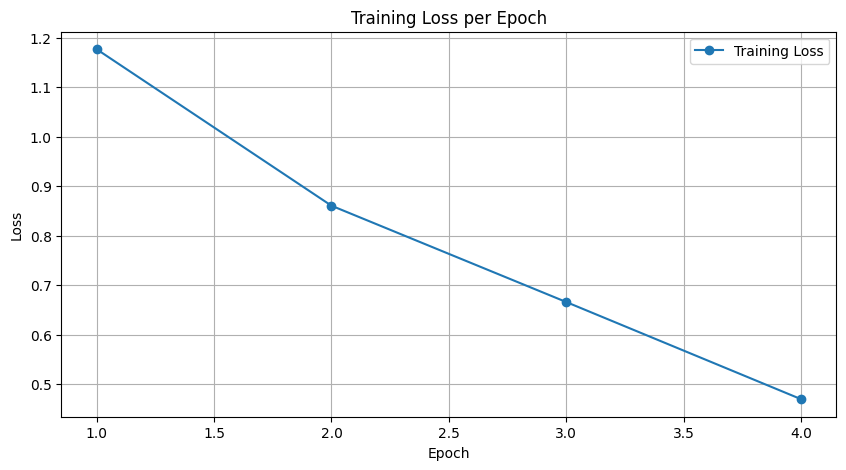

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device: " + device)
vit.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, vit.parameters()), lr=5e-5)

EPOCHS = 10

patience = 2
counter = 0
best_val_acc = 0.0

if not isinstance(vit.head, nn.Sequential):
    vit.head = nn.Sequential(
        nn.LayerNorm(vit.head.in_features),
        nn.Dropout(p=0.5),  # 50% dropout probability
        vit.head
    ).to(device)
train_losses = []

accumulation_steps = 4
i = 0

for epoch in range(EPOCHS):
    vit.train()
    total_loss = 0
    for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, lbls = imgs.to(device), lbls.to(device)
        out = vit(imgs)
        loss = criterion(out, lbls) / accumulation_steps
        loss.backward()
        total_loss += loss.item() * accumulation_steps
        i += 1
        if i % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()
        
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    vit.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for imgs, lbls in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = vit(imgs)
            preds = out.argmax(dim=1)
            val_correct += (preds == lbls).sum().item()
            val_total += lbls.size(0)
    
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc*100:.2f}%")  

    # --- Early Stopping & Saving Check ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0
        torch.save(vit.state_dict(), 'best_emotion_vit.pth')
        print(f"  >>> New best model saved! (Acc: {best_val_acc*100:.2f}%)")
    else:
        counter += 1
        print(f"  No improvement. Early stopping counter: {counter}/{patience}")
        if counter >= patience:
            print("  >>> Early stopping triggered. Training stopped.")
            break

            
# Training Loss
plt.figure(figsize=(10, 5))
epochs_trained = len(train_losses)
plt.plot(range(1, epochs_trained + 1), train_losses, marker='o', label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Image “cleaning” via segmentation

In [13]:
!pip install transformers

Defaulting to user installation because normal site-packages is not writeable


PyTorch Segmentation Model Loaded!


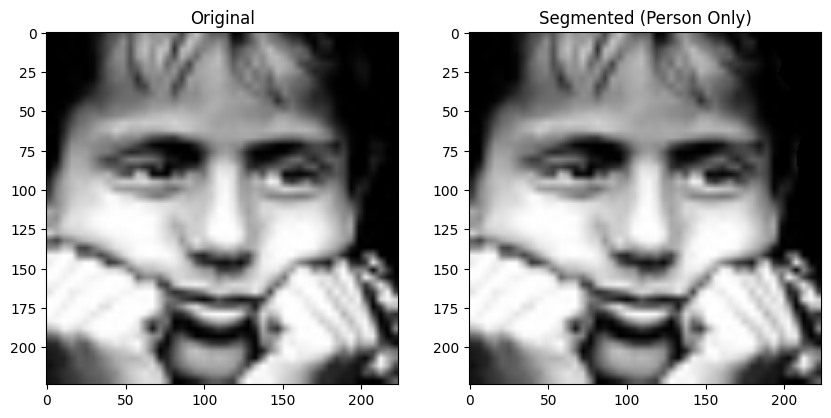

In [ ]:
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights
import torch

# 1. Loading model
weights = FCN_ResNet50_Weights.DEFAULT
seg_model = fcn_resnet50(weights=weights)
seg_model.to(device)
seg_model.eval()

# 2. Defining Normalization
seg_mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
seg_std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

def simple_seg_clean(x_batch):
    """
    Uses FCN-ResNet50 to detect 'Person' (Class 15) and mask the background.
    """
    b, c, h, w = x_batch.shape

    raw_imgs = x_batch * 0.5 + 0.5
    
    seg_inputs = (raw_imgs - seg_mean) / seg_std

    # Inference
    with torch.no_grad():
        outputs = seg_model(seg_inputs)['out'] 
        
        # 4. Get labels
        labels = outputs.argmax(dim=1)
        
        mask = (labels == 15).unsqueeze(1).float()
    
    #Apply mask to original x_batch
    black_pixel_val = -1.0
    cleaned_batch = x_batch * mask + black_pixel_val * (1 - mask)
    
    return cleaned_batch

print("PyTorch Segmentation Model Loaded!")

# Test Visualization
imgs, lbls = next(iter(test_loader))
imgs = imgs.to(device)
clean_imgs = simple_seg_clean(imgs)

# Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(imgs[0].permute(1,2,0).cpu().numpy() * 0.5 + 0.5); plt.title("Original")
plt.subplot(1, 2, 2); plt.imshow(clean_imgs[0].permute(1,2,0).cpu().numpy() * 0.5 + 0.5); plt.title("Segmented (Person Only)")
plt.show()

Evaluation

In [15]:
import time

In [ ]:
# ViT with Image Segmentation
vit.eval()
correct, total = 0, 0
start_time = time.time()
with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc="Testing"):
        imgs, lbls = imgs.to(device), lbls.to(device)
        imgs = simple_seg_clean(imgs)
        out = vit(imgs)
        preds_seg = out.argmax(1)
        correct += (preds_seg == lbls).sum().item()
        total += lbls.numel()
end_time = time.time()
total_inference_time = end_time - start_time
avg_time_per_image = (total_inference_time / total) * 1000
fps = total / total_inference_time
acc = correct / total
print(f"Test accuracy: {acc*100:.2f}%")

print(f"Average Inference Time per Image Incl. Segmentation: {avg_time_per_image:.2f}ms" )

Testing: 100%|██████████| 113/113 [00:41<00:00,  2.71it/s]

Test accuracy: 68.47%
Average Inference Time per Image Incl. Segmentation: 11.61ms


In [17]:
# Evaluation: ViT without Image Segmentation
vit.eval()
correct_no_seg, total_no_seg = 0, 0
start_time = time.time()

with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc="Testing (No Seg)"):
        imgs, lbls = imgs.to(device), lbls.to(device)
        
        # Pass images directly to ViT without the segmentation cleaning step
        out = vit(imgs)
        
        preds_no_seg = out.argmax(1)
        correct_no_seg += (preds_no_seg == lbls).sum().item()
        total_no_seg += lbls.numel()

end_time = time.time()
total_inference_time_ns = end_time - start_time
avg_time_per_image_ns = (total_inference_time_ns / total_no_seg) * 1000
acc_no_seg = correct_no_seg / total_no_seg

print(f"Test Accuracy (No Segmentation): {acc_no_seg*100:.2f}%")
print(f"Average Inference Time per Image (No Segmentation): {avg_time_per_image_ns:.2f}ms")

Testing (No Seg): 100%|██████████| 113/113 [00:22<00:00,  4.96it/s]

Test Accuracy (No Segmentation): 68.11%
Average Inference Time per Image (No Segmentation): 6.35ms


Visualize a few predictions

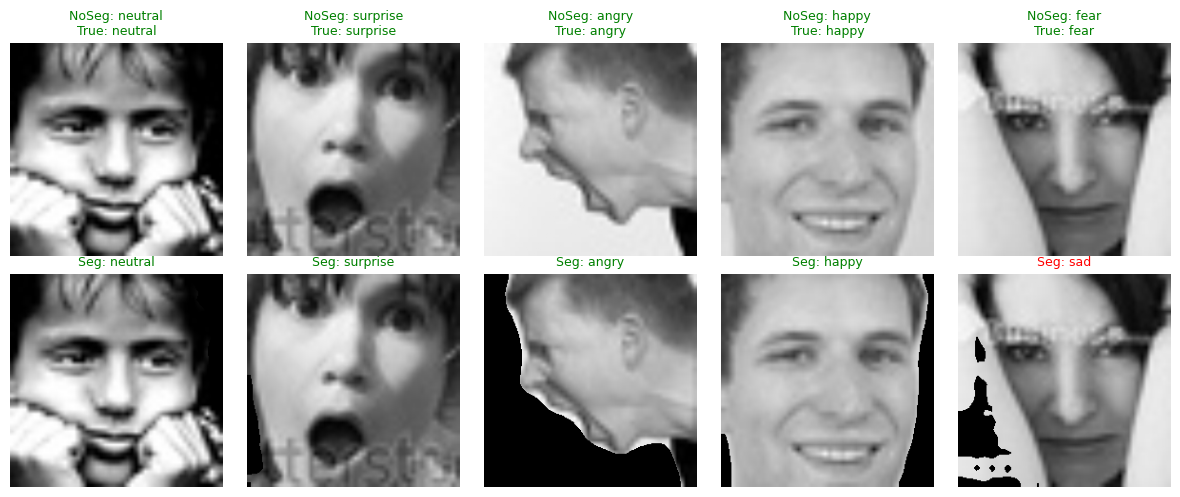

In [ ]:
emotion_names = train_dataset.classes
imgs, lbls = next(iter(test_loader))
imgs = imgs.to(device)

vit.eval()
with torch.no_grad():
    # 1. Prediction on original images
    preds_no_seg = vit(imgs).argmax(1).cpu()
    
    # 2. Prediction on segmented images
    clean_imgs = simple_seg_clean(imgs)
    preds_seg = vit(clean_imgs).argmax(1).cpu()

# Move back to CPU for plotting
imgs = imgs.cpu()
clean_imgs = clean_imgs.cpu()
lbls = lbls.cpu()

plt.figure(figsize=(12, 5))
# Show first 5 images in the batch
for i in range(5):
    # Top Row, w/o Segmentation
    plt.subplot(2, 5, i + 1)
    # De-normalize for display: (x * 0.5) + 0.5 maps [-1, 1] back to [0, 1]
    plt.imshow((imgs[i].permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1))
    
    # Label with Prediction and True
    color = 'green' if preds_no_seg[i] == lbls[i] else 'red'
    plt.title(f"NoSeg: {emotion_names[preds_no_seg[i]]}\nTrue: {emotion_names[lbls[i]]}", 
              color=color, fontsize=9)
    plt.axis('off')

    # Bottom Row, Segmented
    plt.subplot(2, 5, i + 6)
    plt.imshow((clean_imgs[i].permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1))
    
    color = 'green' if preds_seg[i] == lbls[i] else 'red'
    plt.title(f"Seg: {emotion_names[preds_seg[i]]}", 
              color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

Generating Matrix (No Seg): 100%|██████████| 113/113 [00:22<00:00,  4.94it/s]


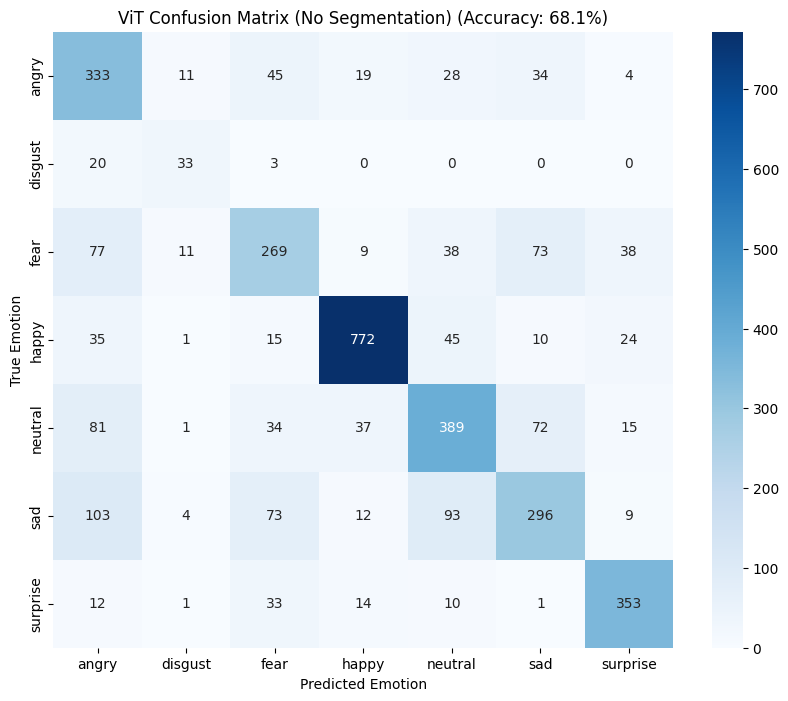

Generating Matrix (Seg): 100%|██████████| 113/113 [00:41<00:00,  2.70it/s]


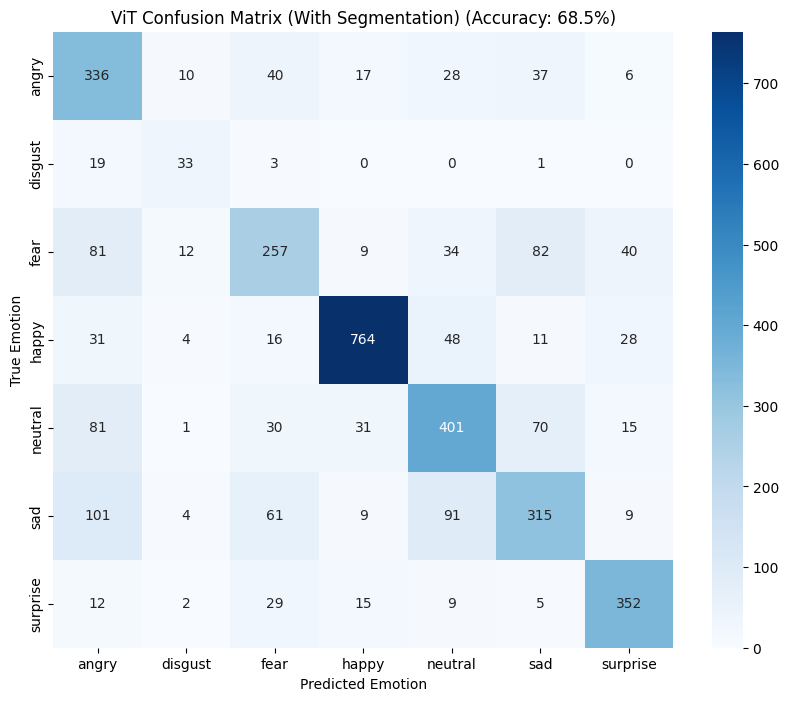

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

def plot_vit_confusion_matrix(y_true, y_pred, classes, title_suffix):
    cm = confusion_matrix(y_true, y_pred)
    # Calculate accuracy from the data
    acc = (y_true == y_pred).sum() / len(y_true)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Emotion')
    plt.ylabel('True Emotion')
    plt.title(f'ViT Confusion Matrix {title_suffix} (Accuracy: {acc*100:.1f}%)')
    plt.show()

# collect all predictions from the loader
def get_all_preds(model, loader, use_segmentation=False):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        desc = "Generating Matrix (Seg)" if use_segmentation else "Generating Matrix (No Seg)"
        for imgs, lbls in tqdm(loader, desc=desc):
            imgs, lbls = imgs.to(device), lbls.to(device)
            
            if use_segmentation:
                imgs = simple_seg_clean(imgs)
            
            out = model(imgs)
            preds = out.argmax(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds)

class_names = train_dataset.classes

# Confusion Matrix, ViT w/o Segmentation
y_true_no_seg, y_pred_no_seg = get_all_preds(vit, test_loader, use_segmentation=False)
plot_vit_confusion_matrix(y_true_no_seg, y_pred_no_seg, class_names, "(No Segmentation)")

# Confusion Matrix: ViT w/ Segmentation
y_true_seg, y_pred_seg = get_all_preds(vit, test_loader, use_segmentation=True)
plot_vit_confusion_matrix(y_true_seg, y_pred_seg, class_names, "(With Segmentation)")

In [21]:
!pip install git+https://github.com/openai/CLIP.git
!pip install matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-5uyixkfw
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-5uyixkfw
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
Defaulting to user installation because normal site-packages is not writeable


Starting Evaluation...

CLIP Zero-Shot Accuracy Without Segmentation: 49.81%


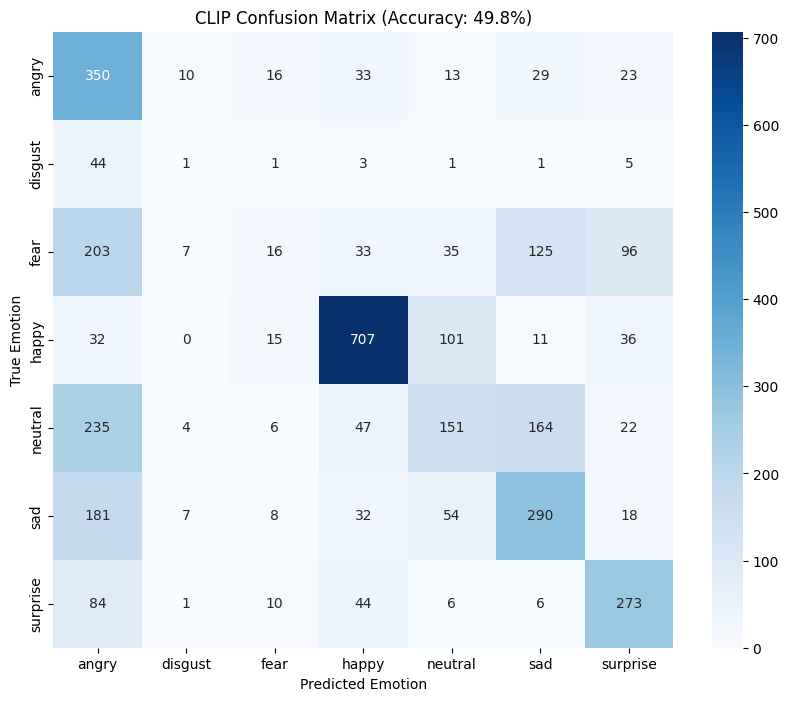


Classification Report:

              precision    recall  f1-score   support

       angry       0.31      0.74      0.44       474
     disgust       0.03      0.02      0.02        56
        fear       0.22      0.03      0.05       515
       happy       0.79      0.78      0.79       902
     neutral       0.42      0.24      0.31       629
         sad       0.46      0.49      0.48       590
    surprise       0.58      0.64      0.61       424

    accuracy                           0.50      3590
   macro avg       0.40      0.42      0.38      3590
weighted avg       0.49      0.50      0.47      3590



In [ ]:
import torch
import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from torch.utils.data import DataLoader, Dataset
import os

# Loading model
model, preprocess = clip.load("ViT-B/32", device=device)

# Emotion classes
class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

text_prompts = [f"a photo of a face showing {emotion}" for emotion in class_names]

# Pre-tokenized
text_inputs = clip.tokenize(text_prompts).to(device)

# 3. Data Loading
class EmotionDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label

# Evaluation Function
def evaluate_clip(model, loader, text_inputs):
    model.eval()
    all_preds = []
    all_labels = []
    
    # Calculate text features
    with torch.no_grad():
        text_features = model.encode_text(text_inputs)
        text_features /= text_features.norm(dim=-1, keepdim=True)

    print("Starting Evaluation...")
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            
            # Calculate Similarity 
            similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
            
            # Get predictions
            values, indices = similarity.topk(1)
            preds = indices.squeeze().cpu().numpy()
            
            all_preds.extend(np.atleast_1d(preds))
            all_labels.extend(labels.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds)

# Evaluation
if 'test_loader' in locals() and len(test_loader) > 0:
    y_true, y_pred = evaluate_clip(model, test_loader, text_inputs)

    acc = accuracy_score(y_true, y_pred)
    print(f"\nCLIP Zero-Shot Accuracy Without Segmentation: {acc * 100:.2f}%")

    # Confusion Matrix
    def plot_confusion_matrix(y_true, y_pred, classes):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=classes, yticklabels=classes)
        plt.xlabel('Predicted Emotion')
        plt.ylabel('True Emotion')
        plt.title(f'CLIP Confusion Matrix (Accuracy: {acc*100:.1f}%)')
        plt.show()

    plot_confusion_matrix(y_true, y_pred, class_names)
    
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

else:
    print("Please define 'test_loader' with your dataset to run the evaluation.")

Starting Evaluation with Segmentation...

CLIP Zero-Shot Accuracy With Segmentation: 36.99%


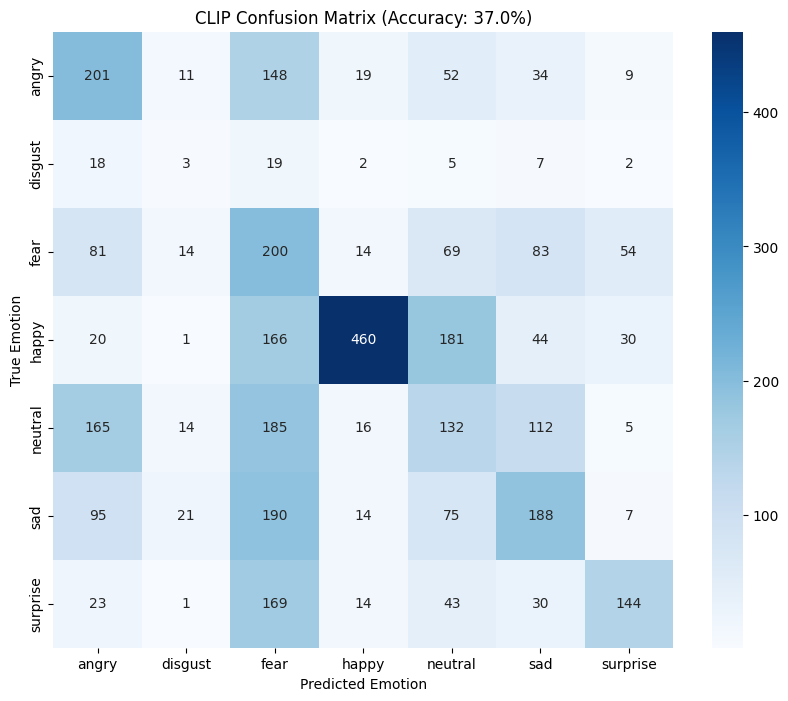


Classification Report:

              precision    recall  f1-score   support

       angry       0.33      0.42      0.37       474
     disgust       0.05      0.05      0.05        56
        fear       0.19      0.39      0.25       515
       happy       0.85      0.51      0.64       902
     neutral       0.24      0.21      0.22       629
         sad       0.38      0.32      0.35       590
    surprise       0.57      0.34      0.43       424

    accuracy                           0.37      3590
   macro avg       0.37      0.32      0.33      3590
weighted avg       0.46      0.37      0.39      3590



In [ ]:
# CLIP w/ image segmentation
def evaluate_clip_with_segmentation(model, loader, text_inputs, seg_fn):
    model.eval()
    all_preds = []
    all_labels = []
    
    # Calculate text features
    with torch.no_grad():
        text_features = model.encode_text(text_inputs)
        text_features /= text_features.norm(dim=-1, keepdim=True)

    print("Starting Evaluation with Segmentation...")
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            # Segment
            images = seg_fn(images)
            
            # Encode Images
            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            
            # Calculate Similarity
            similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
            
            values, indices = similarity.topk(1)
            preds = indices.squeeze().cpu().numpy()
            
            all_preds.extend(np.atleast_1d(preds))
            all_labels.extend(labels.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds)


# Evaluation
if 'test_loader' in locals() and len(test_loader) > 0:
    y_true_seg, y_pred_seg = evaluate_clip_with_segmentation(
        model, 
        test_loader, 
        text_inputs, 
        simple_seg_clean
    )

    acc_seg = accuracy_score(y_true_seg, y_pred_seg)
    print(f"\nCLIP Zero-Shot Accuracy With Segmentation: {acc_seg * 100:.2f}%")

    # Confusion Matrix
    def plot_confusion_matrix(y_true, y_pred, classes, acc):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=classes, yticklabels=classes)
        plt.xlabel('Predicted Emotion')
        plt.ylabel('True Emotion')
        plt.title(f'CLIP Confusion Matrix (Accuracy: {acc*100:.1f}%)')
        plt.show()

    plot_confusion_matrix(y_true_seg, y_pred_seg, class_names, acc_seg)

    print("\nClassification Report:\n")
    print(classification_report(y_true_seg, y_pred_seg, target_names=class_names))

else:
    print("Please define 'test_loader' with your dataset to run the evaluation.")